In [2]:
import os
import librosa
import kaggle
import numpy as np
from glob import glob
from pathlib import Path
import pandas as pd
import math
import gc

from matplotlib import pyplot as plt

download recordings

In [3]:
if not os.path.exists("./data"):
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('quochoangvuvan/ml-voice-recognition', path=".", unzip=True)
    print(kaggle.api.dataset_list_files('quochoangvuvan/ml-voice-recognition').files)
    kaggle.api.dataset_metadata('quochoangvuvan/ml-voice-recognition', path=".")

#class0_files = glob("./data/Class0/*/*.mp3")
#class1_files = glob("./data/Class1/*/*.mp3")

class0_dirs = [d for d in Path("../preprocessing_pipeline/data/Class0").iterdir()]
class0_speakers = {}
for speaker_dir in class0_dirs:
    speaker_name = speaker_dir.name
    audio_files = list(speaker_dir.glob('*.mp3'))
    class0_speakers[speaker_name] = audio_files

nosie_dirs = [d for d in Path("../preprocessing_pipeline/data/Random_Noise").iterdir()]
noise_types = {}
for noise in nosie_dirs:
    noise_type = f"noise_{noise.name}"
    audio_files = list(noise.glob('*.mp3'))
    noise_types[noise_type] = audio_files

class1_dirs = [d for d in Path("../preprocessing_pipeline/data/Class1").iterdir()]
class1_speakers = {}
for speaker_dir in class1_dirs:
    speaker_name = speaker_dir.name
    audio_files = list(speaker_dir.glob('*.mp3'))
    class1_speakers[speaker_name] = audio_files



In [4]:
from collections import defaultdict
recording_lengths_class0_people = []
recording_lengths_class1 = []
recording_lengths_class0_noise = []

speaker_lengths_class0 = {}
speaker_lengths_class1 = {}
noise_lengths_class0 = {}

speaker_number_of_recordings_class0 = defaultdict(int)
speaker_number_of_recordings_class1 = defaultdict(int)
noise_number_of_recordings_class0 = defaultdict(int)

for speaker, files in class0_speakers.items():
    total = 0
    for f in files:
        y, sr = librosa.load(f, sr=None)
        length = len(y) / sr
        recording_lengths_class0_people.append(length)
        total += length
        speaker_number_of_recordings_class0[speaker] += 1
        del y, sr
    speaker_lengths_class0[speaker] = total
    gc.collect()

for speaker, files in class1_speakers.items():
    total = 0
    for f in files:
        y, sr = librosa.load(f, sr=None)
        length = len(y) / sr
        recording_lengths_class1.append(length)
        total += length
        speaker_number_of_recordings_class1[speaker] += 1
        del y,sr
    speaker_lengths_class1[speaker] = total
    gc.collect()

for ntype, files in noise_types.items():
    total = 0
    for f in files:
        y, sr = librosa.load(f, sr=None)
        length = len(y) / sr
        recording_lengths_class0_noise.append(length)
        total += length
        noise_number_of_recordings_class0[ntype] += 1
        del y,sr
    noise_lengths_class0[ntype] = total
    gc.collect()

recording_lengths_class0 = recording_lengths_class0_people + recording_lengths_class0_noise

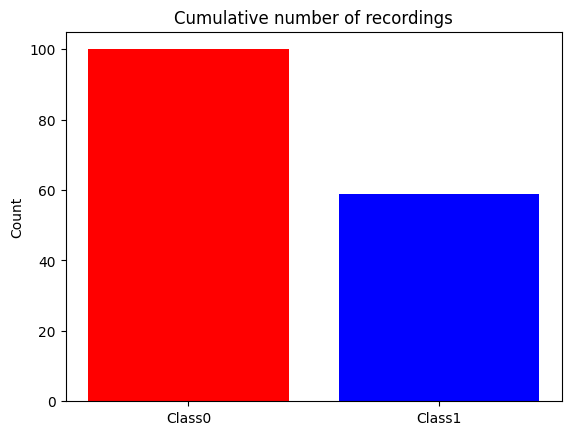

In [5]:
# cumulative number of recordings in class1, in class0  barplot
counts = [len(recording_lengths_class0), len(recording_lengths_class1)]

plt.bar(["Class0", "Class1"], counts, color=["red", "blue"])
plt.title("Cumulative number of recordings")
plt.ylabel("Count")
plt.show()

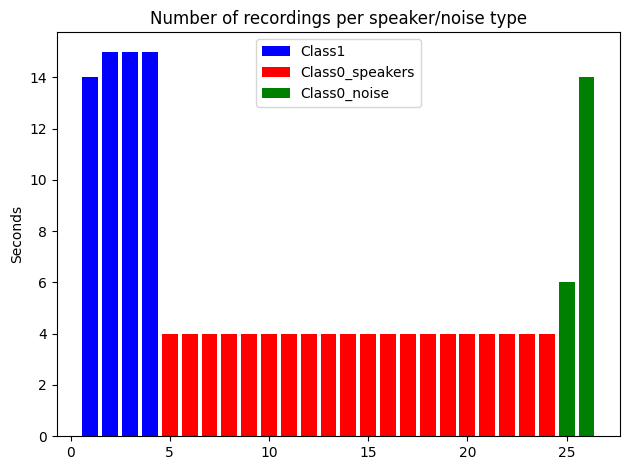

In [6]:
plt.figure()

num_sp_0 = len(speaker_lengths_class0)
num_sp_1 = len(speaker_lengths_class1)
num_noise_0 = len(noise_lengths_class0)

plt.bar(range(1, 1+num_sp_1),
        list(speaker_number_of_recordings_class1.values()),
        color="blue",
        label="Class1")

plt.bar(range(1+num_sp_1, 1+num_sp_1+num_sp_0),
        list(speaker_number_of_recordings_class0.values()),
        color="red",
        label="Class0_speakers")

plt.bar(range(1+num_sp_1+num_sp_0, 1+num_sp_1+num_sp_0+num_noise_0),
        list(noise_number_of_recordings_class0.values()),
        color="green",
        label="Class0_noise")

plt.title("Number of recordings per speaker/noise type")
plt.ylabel("Seconds")
plt.legend()
plt.tight_layout()
plt.show()

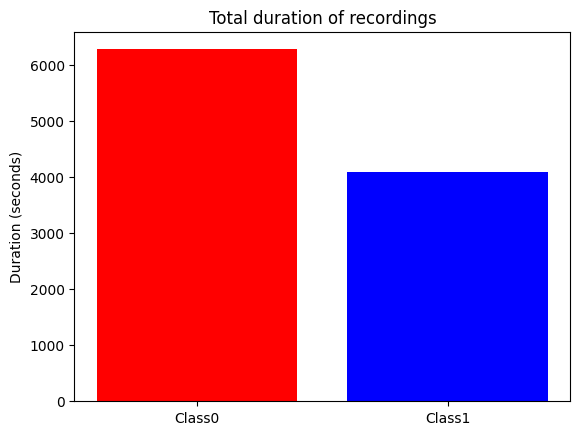

In [7]:
# cumulative length of recordings in class1, in class0  barplot
total_len_class0 = sum(recording_lengths_class0)
total_len_class1 = sum(recording_lengths_class1)

plt.bar(["Class0", "Class1"], [total_len_class0, total_len_class1], color=["red", "blue"])
plt.title("Total duration of recordings")
plt.ylabel("Duration (seconds)")
plt.show()

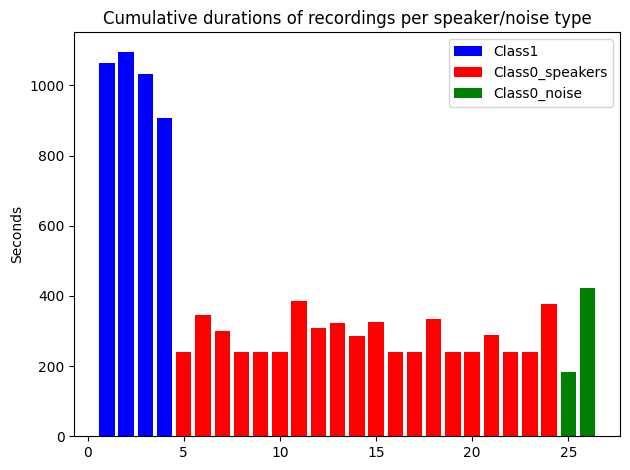

In [8]:
#cumulative length of recordings per speaker in class1, per speaker in class0 and per noise type in class 0 type barplot
plt.figure()

num_sp_0 = len(speaker_lengths_class0)
num_sp_1 = len(speaker_lengths_class1)
num_noise_0 = len(noise_lengths_class0)

plt.bar(range(1, 1+num_sp_1),
        list(speaker_lengths_class1.values()),
        color="blue",
        label="Class1")

plt.bar(range(1+num_sp_1, 1+num_sp_1+num_sp_0),
        list(speaker_lengths_class0.values()),
        color="red",
        label="Class0_speakers")



plt.bar(range(1+num_sp_1+num_sp_0, 1+num_sp_1+num_sp_0+num_noise_0),
        list(noise_lengths_class0.values()),
        color="green",
        label="Class0_noise")



plt.title("Cumulative durations of recordings per speaker/noise type")
plt.ylabel("Seconds")
plt.legend()
plt.tight_layout()
plt.show()

We have 2 types of noise: random people and random sounds

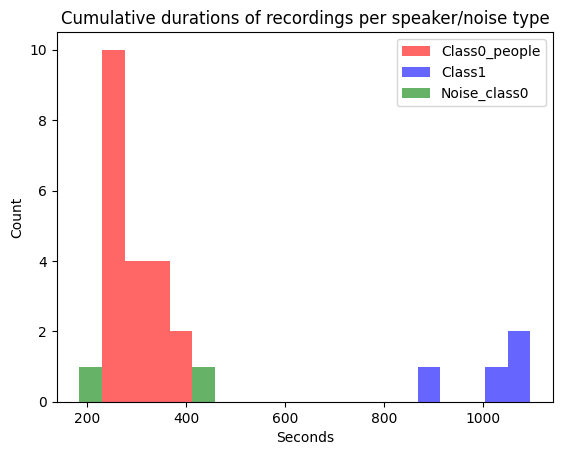

In [9]:
#cumulative length of recordings per speaker in class1, per speaker in class0 and per noise typein class 0 type histogram

#equal width of rectangles
all_lengths = (list(speaker_lengths_class0.values()) +
               list(speaker_lengths_class1.values()) +
               list(noise_lengths_class0.values()))
bins = np.linspace(min(all_lengths), max(all_lengths), 21)

plt.figure()
plt.hist(list(speaker_lengths_class0.values()), bins=bins, alpha=0.6, color='red', label="Class0_people")
plt.hist(list(speaker_lengths_class1.values()), bins=bins, alpha=0.6, color='blue', label="Class1")
plt.hist(list(noise_lengths_class0.values()), bins=bins, alpha=0.6, color='green', label="Noise_class0")
plt.title("Cumulative durations of recordings per speaker/noise type")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.legend()
plt.show()

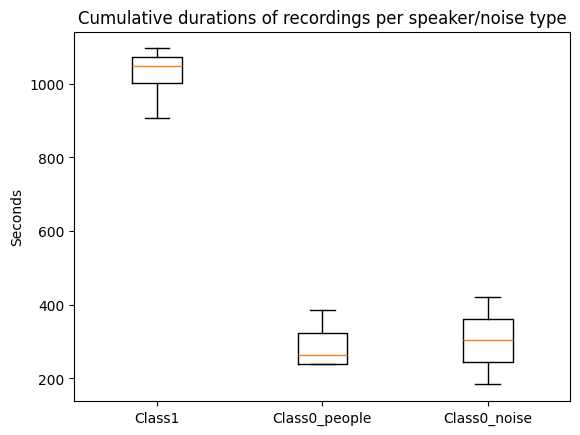

In [10]:
#cumulative length of recordings per speaker in class1, per speaker in class0 and per noise typein class 0 type boxplot

plt.figure()
plt.boxplot([list(speaker_lengths_class1.values()),list(speaker_lengths_class0.values()),
             list(noise_lengths_class0.values())], tick_labels=["Class1", "Class0_people", "Class0_noise"])
plt.title("Cumulative durations of recordings per speaker/noise type")
plt.ylabel("Seconds")
plt.show()

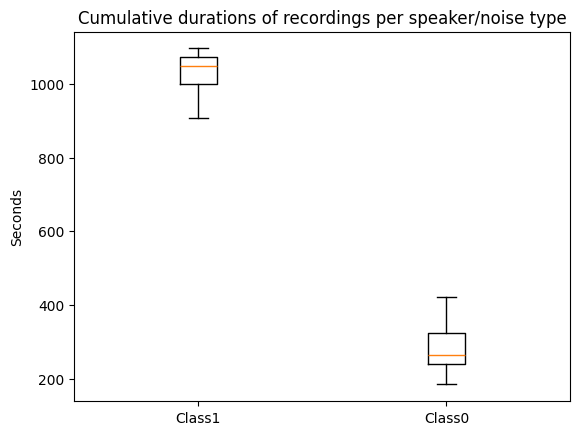

In [11]:
#just as above but class 0 cumulative noise and people
plt.figure()
plt.boxplot([list(speaker_lengths_class1.values()),list(speaker_lengths_class0.values()) + list(noise_lengths_class0.values())], tick_labels=["Class1", "Class0"])
plt.title("Cumulative durations of recordings per speaker/noise type")
plt.ylabel("Seconds")
plt.show()

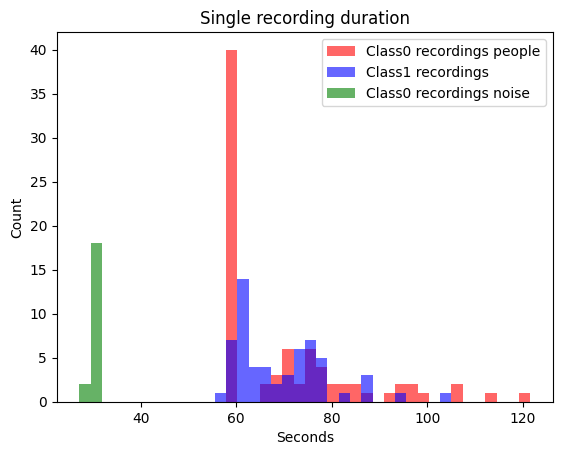

In [12]:
#length of a single recording in class1, single recording of a speaker in class0 and single recording of noise in class 0 type histogram


all_lengths = (recording_lengths_class0_people +
               recording_lengths_class1 +
               recording_lengths_class0_noise)
bins = np.linspace(min(all_lengths), max(all_lengths), 41)
plt.figure()
plt.hist(recording_lengths_class0_people, bins=bins, alpha=0.6, color='red', label="Class0 recordings people")
plt.hist(recording_lengths_class1, bins=bins, alpha=0.6, color='blue', label="Class1 recordings")
plt.hist(recording_lengths_class0_noise, bins=bins, alpha=0.6, color='green', label="Class0 recordings noise")
plt.title("Single recording duration")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.legend()
plt.show()

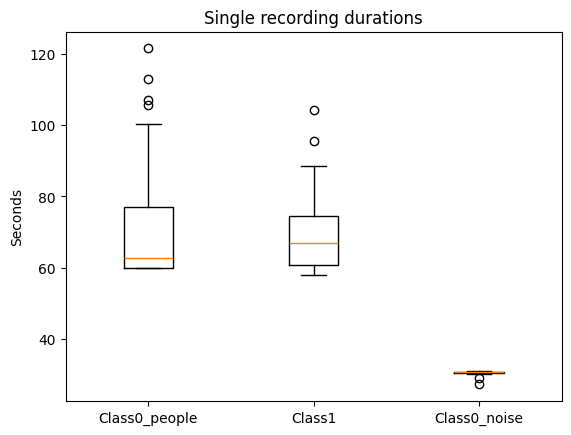

In [13]:
#length of a single recording in class1, single recording of a speaker in class0 and single recording of noise in class 0 type boxplots
plt.figure()
plt.boxplot([recording_lengths_class0_people, recording_lengths_class1, recording_lengths_class0_noise], tick_labels=["Class0_people", "Class1", "Class0_noise"])
plt.title("Single recording durations")
plt.ylabel("Seconds")
plt.show()

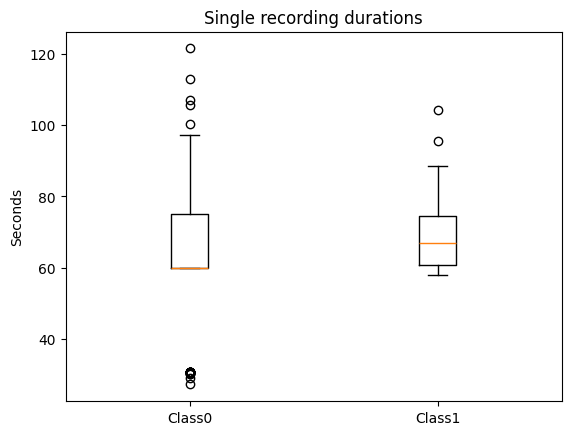

In [14]:
#length of a single recording in class1, and single recording in class 0 type boxplot
plt.figure()
plt.boxplot([recording_lengths_class0, recording_lengths_class1], tick_labels=["Class0", "Class1"])
plt.title("Single recording durations")
plt.ylabel("Seconds")
plt.show()

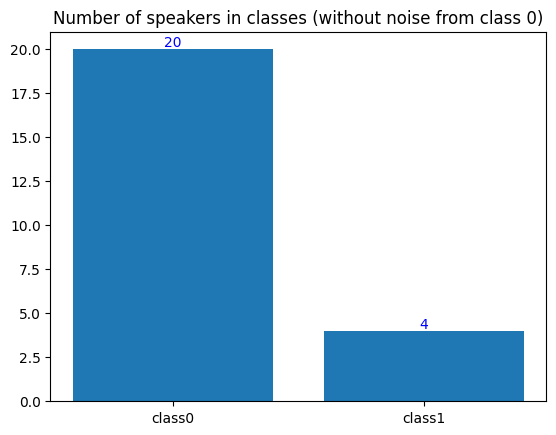

In [15]:

class0_count = len(class0_speakers)
class1_count = len(class1_speakers)
fig, ax = plt.subplots()
x_positions = [0, 1]
bars = ax.bar(['class0', 'class1'], [class0_count, class1_count])
ax.bar_label(bars, label_type='edge', color='blue')
ax.title.set_text('Number of speakers in classes (without noise from class 0)')
plt.show()

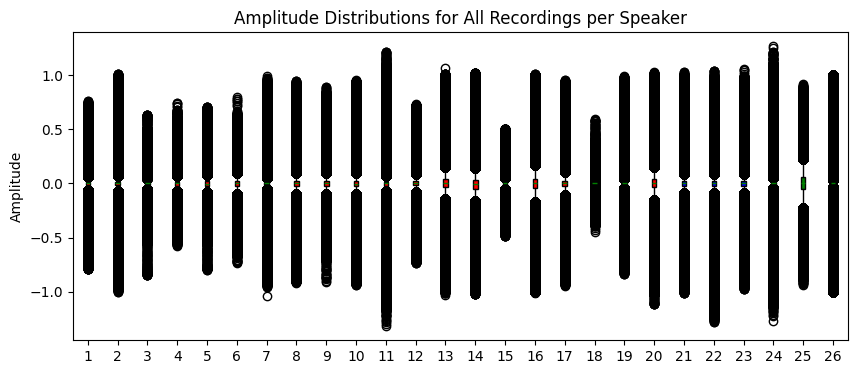

In [16]:
import gc

fig, ax = plt.subplots(figsize=(10,4))
current_position = 1


for speaker in class0_speakers:
    speaker_arr = np.concatenate([librosa.load(audio_file, sr=None)[0] for audio_file in class0_speakers[speaker]])
    ax.boxplot(speaker_arr, label=f"Class0_{speaker}", positions=[current_position], patch_artist=True,
                boxprops=dict(facecolor="red"), medianprops=dict(color='green'))
    del speaker_arr
    current_position += 1
gc.collect()


for speaker in class1_speakers:
    speaker_arr = np.concatenate([librosa.load(audio_file, sr=None)[0] for audio_file in class1_speakers[speaker]])
    ax.boxplot(speaker_arr, label=f"Class1_{speaker}", positions=[current_position], patch_artist=True,
                boxprops=dict(facecolor="blue"),medianprops=dict(color='green'))
    del speaker_arr
    current_position += 1
gc.collect()

for noise in noise_types:
    speaker_arr = np.concatenate([librosa.load(audio_file, sr=None)[0] for audio_file in noise_types[noise]])
    ax.boxplot(speaker_arr, label=f"Class0_{noise}", positions=[current_position], patch_artist=True,
                boxprops=dict(facecolor="green"),medianprops=dict(color='green'))
    del speaker_arr
    current_position += 1
gc.collect()

ax.set_title('Amplitude Distributions for All Recordings per Speaker')
ax.set_ylabel('Amplitude')
plt.show()

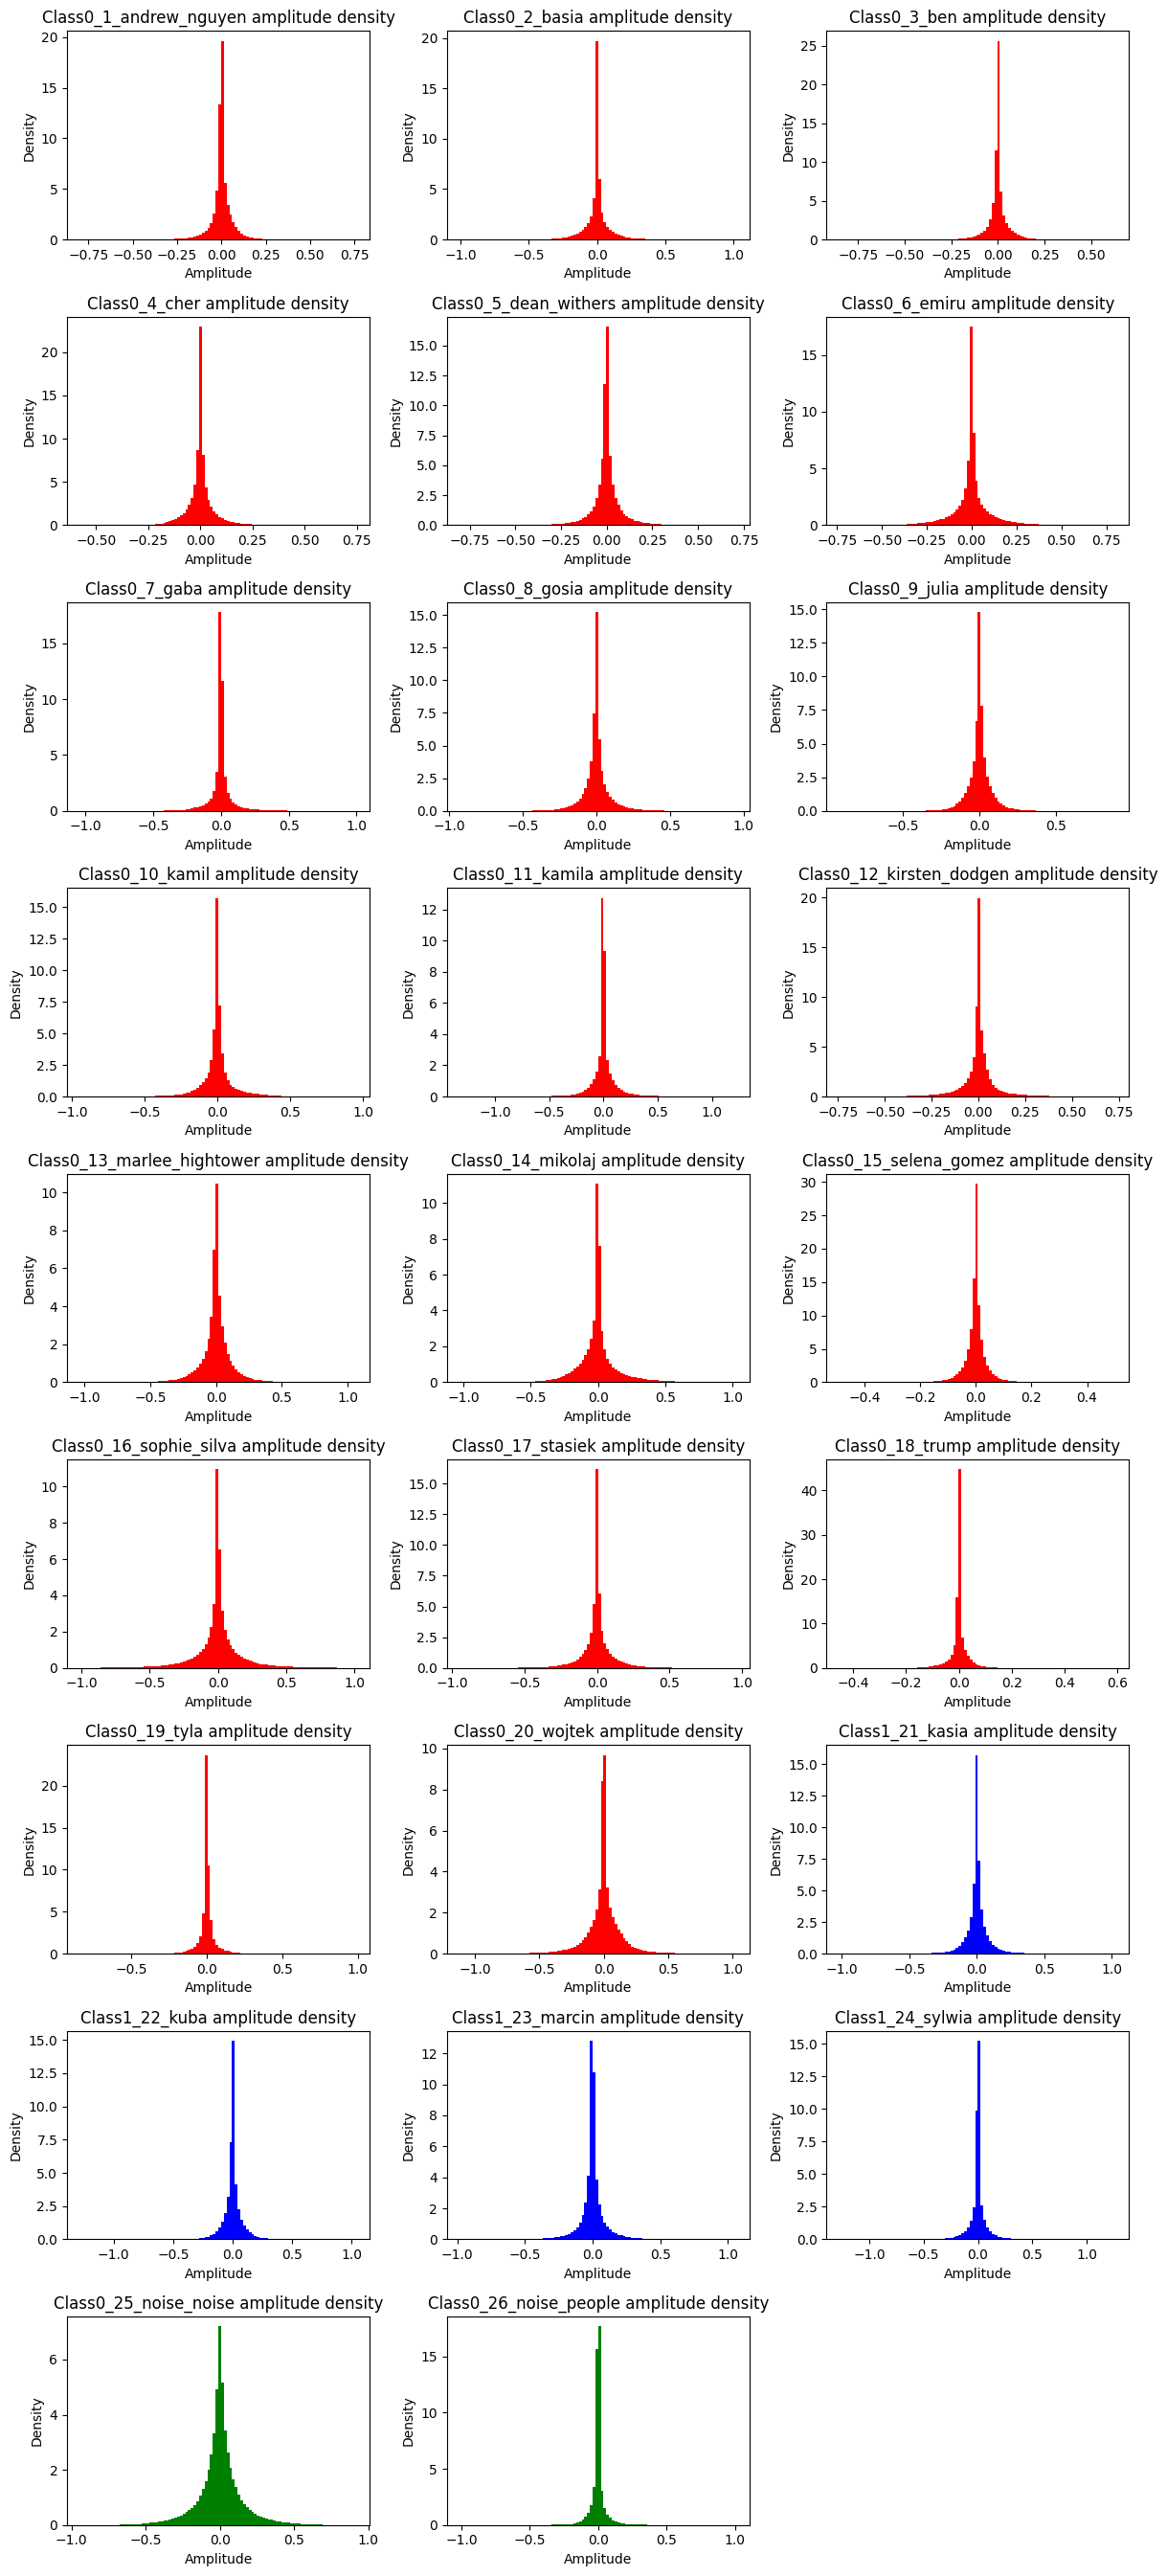

In [17]:

n_speakers = class0_count+class1_count+len(noise_types)
n_cols = min(3, n_speakers)
n_rows = math.ceil(n_speakers / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
current_position = 1

speaker_class0_stats = {}
speaker_class1_stats = {}
noise_class0_stats = {}

recording_class0_people_stats = {}
recording_class1_stats = {}
recording_class0_noise_stats = {}

for speaker in class0_speakers:
    arrays = []
    for audio_file in class0_speakers[speaker]:
        y, sr = librosa.load(audio_file, sr=None)
        arrays.append(y)

        recording_class0_people_stats[audio_file] = {
            "mean": (np.mean(y)),
            "std": (np.std(y)),
            "min": (np.min(y)),
            "max": (np.max(y))
        }

    speaker_arr = np.concatenate(arrays)

    axes[current_position-1].hist(speaker_arr, bins=100, density=True, color="red")
    axes[current_position-1].set_title(f"Class0_{current_position}_{speaker} amplitude density")
    axes[current_position-1].set_xlabel("Amplitude")
    axes[current_position-1].set_ylabel("Density")

    speaker_class0_stats[f"{speaker}"] = {
        "position": current_position,
        "mean": (np.mean(speaker_arr)),
        "std": (np.std(speaker_arr)),
        "min": (np.min(speaker_arr)),
        "max": (np.max(speaker_arr))
    }

    del speaker_arr, arrays
    gc.collect()

    current_position += 1

for speaker in class1_speakers:
    arrays = []
    for audio_file in class1_speakers[speaker]:
        y, sr = librosa.load(audio_file, sr=None)
        arrays.append(y)

        recording_class1_stats[audio_file] = {
            "mean": (np.mean(y)),
            "std": (np.std(y)),
            "min": (np.min(y)),
            "max": (np.max(y))
        }

    speaker_arr = np.concatenate(arrays)

    axes[current_position-1].hist(speaker_arr, bins=100, density=True, color="blue")
    axes[current_position-1].set_title(f"Class1_{current_position}_{speaker} amplitude density")
    axes[current_position-1].set_xlabel("Amplitude")
    axes[current_position-1].set_ylabel("Density")

    speaker_class1_stats[f"{speaker}"] = {
        "position": current_position,
        "mean":(np.mean(speaker_arr)),
        "std": (np.std(speaker_arr)),
        "min": (np.min(speaker_arr)),
        "max": (np.max(speaker_arr))
    }

    del speaker_arr, arrays
    gc.collect()

    current_position += 1

for speaker in noise_types:
    arrays = []
    for audio_file in noise_types[speaker]:
        y, sr = librosa.load(audio_file, sr=None)
        arrays.append(y)

        recording_class0_noise_stats[audio_file] = {
            "mean": (np.mean(y)),
            "std": (np.std(y)),
            "min": (np.min(y)),
            "max": (np.max(y))
        }

    speaker_arr = np.concatenate(arrays)

    axes[current_position-1].hist(speaker_arr, bins=100, density=True, color="green")
    axes[current_position-1].set_title(f"Class0_{current_position}_{speaker} amplitude density")
    axes[current_position-1].set_xlabel("Amplitude")
    axes[current_position-1].set_ylabel("Density")

    noise_class0_stats[f"{speaker}"] = {
        "position": current_position,
        "mean":(np.mean(speaker_arr)),
        "std": (np.std(speaker_arr)),
        "min": (np.min(speaker_arr)),
        "max": (np.max(speaker_arr))
    }

    del speaker_arr, arrays
    gc.collect()

    current_position += 1

#hide unused subplots
for i in range(current_position-1, len(axes)):
    axes[i].axis('off')

fig.tight_layout()
plt.show()


In [18]:

df0 = pd.DataFrame.from_dict(speaker_class0_stats, orient="index")
df0["class"] = "class0_person"

df1 = pd.DataFrame.from_dict(speaker_class1_stats, orient="index")
df1["class"] = "class1"

df_noise = pd.DataFrame.from_dict(noise_class0_stats, orient="index")
df_noise["class"] = "class0_noise"

df_all = pd.concat([df0, df1, df_noise], axis=0)

df_all.index.name = "speaker"

df_all

,position,mean,std,min,max,class
speaker,,,,,,
andrew_nguyen,1,-8.437112e-06,0.060526,-0.792866,0.758528,class0_person
basia,2,-1.600777e-05,0.090405,-1.000177,1.013791,class0_person
ben,3,-4.554196e-06,0.049469,-0.845176,0.630413,class0_person
cher,4,-7.933613e-05,0.063638,-0.573368,0.746141,class0_person
dean_withers,5,-2.538043e-05,0.077516,-0.799274,0.705093,class0_person
emiru,6,3.359154e-05,0.099118,-0.731364,0.801163,class0_person
gaba,7,4.971288e-07,0.084568,-1.034990,0.995206,class0_person
gosia,8,4.972453e-06,0.089348,-0.921193,0.946717,class0_person
julia,9,9.704378e-08,0.071492,-0.909643,0.888127,class0_person


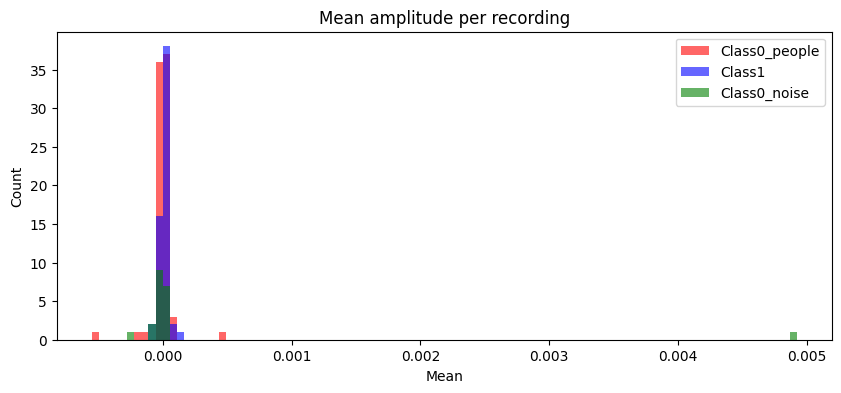

In [19]:
plt.figure(figsize=(10,4))
all_lengths = ([v["mean"] for v in recording_class0_people_stats.values()] +
               [v["mean"] for v in recording_class1_stats.values()] +
               [v["mean"] for v in recording_class0_noise_stats.values()])
bins = np.linspace(min(all_lengths), max(all_lengths), 101)

plt.hist([v["mean"] for v in recording_class0_people_stats.values()], bins=bins, alpha=0.6, color='red', label='Class0_people')
plt.hist([v["mean"] for v in recording_class1_stats.values()], bins=bins, alpha=0.6, color='blue', label='Class1')
plt.hist([v["mean"] for v in recording_class0_noise_stats.values()], bins=bins, alpha=0.6, color='green', label='Class0_noise')
plt.title("Mean amplitude per recording")
plt.xlabel("Mean")
plt.ylabel("Count")
plt.legend()
plt.show()

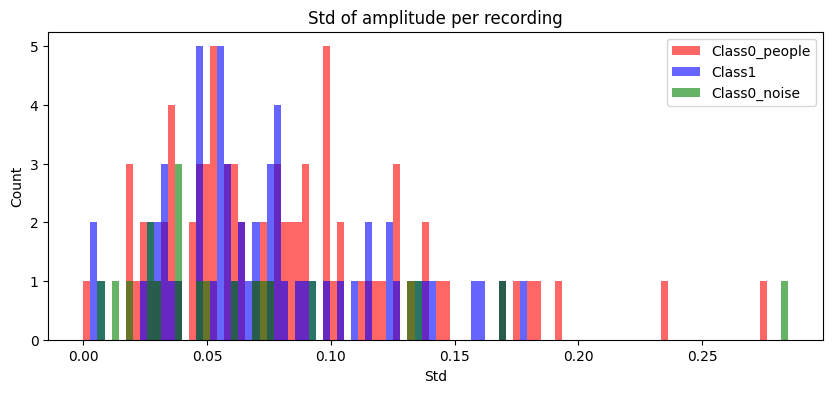

In [20]:
plt.figure(figsize=(10,4))
all_lengths = ([v["std"] for v in recording_class0_people_stats.values()] +
               [v["std"] for v in recording_class1_stats.values()] +
               [v["std"] for v in recording_class0_noise_stats.values()])
bins = np.linspace(min(all_lengths), max(all_lengths), 101)
plt.hist([v["std"] for v in recording_class0_people_stats.values()], bins=bins, alpha=0.6, color='red', label='Class0_people')
plt.hist([v["std"] for v in recording_class1_stats.values()], bins=bins, alpha=0.6, color='blue', label='Class1')
plt.hist([v["std"] for v in recording_class0_noise_stats.values()], bins=bins, alpha=0.6, color='green', label='Class0_noise')
plt.title("Std of amplitude per recording")

plt.xlabel("Std")
plt.ylabel("Count")
plt.legend()
plt.show()

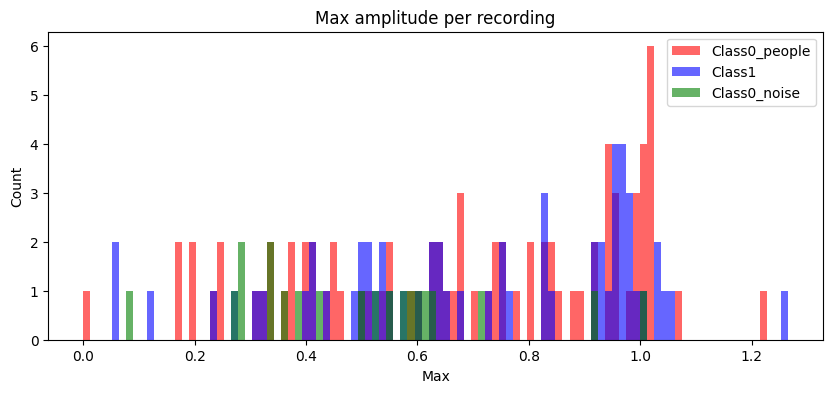

In [21]:
plt.figure(figsize=(10,4))
all_lengths = ([v["max"] for v in recording_class0_people_stats.values()] +
               [v["max"] for v in recording_class1_stats.values()] +
               [v["max"] for v in recording_class0_noise_stats.values()])
bins = np.linspace(min(all_lengths), max(all_lengths), 101)
plt.hist([v["max"] for v in recording_class0_people_stats.values()], bins=bins, alpha=0.6, color='red', label='Class0_people')
plt.hist([v["max"] for v in recording_class1_stats.values()], bins=bins, alpha=0.6, color='blue', label='Class1')
plt.hist([v["max"] for v in recording_class0_noise_stats.values()], bins=bins, alpha=0.6, color='green', label='Class0_noise')
plt.title("Max amplitude per recording")
plt.xlabel("Max")
plt.ylabel("Count")
plt.legend()
plt.show()

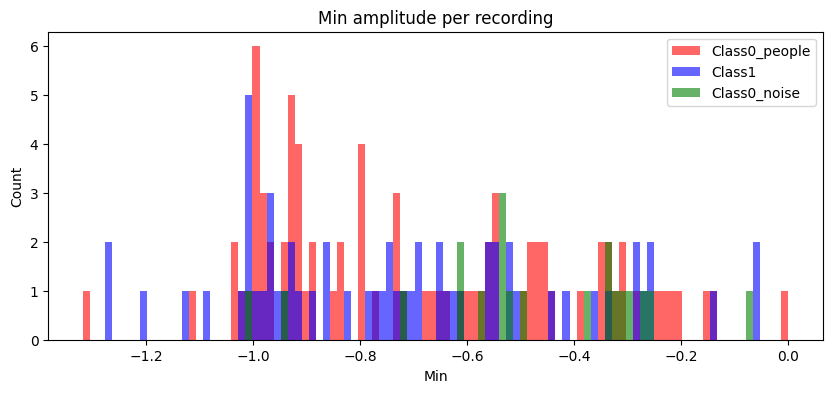

In [22]:
g plt.figure(figsize=(10,4))
all_lengths = ([v["min"] for v in recording_class0_people_stats.values()] +
               [v["min"] for v in recording_class1_stats.values()] +
               [v["min"] for v in recording_class0_noise_stats.values()])
bins = np.linspace(min(all_lengths), max(all_lengths), 101)
plt.hist([v["min"] for v in recording_class0_people_stats.values()], bins=bins, alpha=0.6, color='red', label='Class0_people')
plt.hist([v["min"] for v in recording_class1_stats.values()], bins=bins, alpha=0.6, color='blue', label='Class1')
plt.hist([v["min"] for v in recording_class0_noise_stats.values()], bins=bins, alpha=0.6, color='green', label='Class0_noise')
plt.title("Min amplitude per recording")
plt.xlabel("Min")
plt.ylabel("Count")
plt.legend()
plt.show()